In [1]:
# Cell 1: Setup & Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set academic plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Define directories (Stepping up one level from /notebooks to the root)
results_dir = "../reports/results"
os.makedirs(results_dir, exist_ok=True)

# Load the dataset
csv_path = os.path.join(results_dir, "eval_results.csv")
df = pd.read_csv(csv_path)

print(f"Loaded evaluation data: {df.shape[0]} runs and {df.shape[1]} metrics.")
display(df.head())

Loaded evaluation data: 18 runs and 21 metrics.


,Dataset,Preset,Executed Route,Runtime (s),Supervisor Latency (s),Worker Compute (s),Supervisor Tokens,Worker Tokens,Total Tokens,Supervisor API Calls,...,Total API Calls,Model Name,Accuracy,Precision,Recall,F1 Score,Training Time (s),Judge: Tech,Judge: Action,Judge: Align
0,Heart_Disease_1K,RAPID_BASELINE,data_cleaning -> feature_engineering -> modell...,7.92,1.12,6.80,578,4411,4989,1,...,5,LogisticRegression,0.8152,0.8152,0.8152,0.8152,0.0000,8,8,10
1,Heart_Disease_1K,QUICK_EXPLAINABLE,data_cleaning -> feature_engineering -> modell...,9.62,0.93,8.69,592,4868,5460,1,...,5,DecisionTreeClassifier,0.8152,0.8188,0.8152,0.8162,0.0435,9,8,9
2,Heart_Disease_1K,ENTERPRISE_STANDARD,data_cleaning -> eda -> feature_engineering ->...,24.40,0.96,23.44,603,9089,9692,1,...,6,RandomForestClassifier,0.8750,0.8774,0.8750,0.8755,2.0186,9,8,9
3,Heart_Disease_1K,KAGGLE_COMPETITOR,data_cleaning -> eda -> feature_engineering ->...,40.06,1.15,38.91,599,9597,10196,1,...,6,LGBMClassifier,0.8859,0.8859,0.8859,0.8856,22.5468,10,8,9
4,Heart_Disease_1K,REGULATORY_COMPLIANCE,data_cleaning -> eda -> feature_engineering ->...,11.64,0.91,10.73,593,7197,7790,1,...,6,DecisionTreeClassifier,0.8539,0.8534,0.8539,0.8532,0.0187,9,9,10


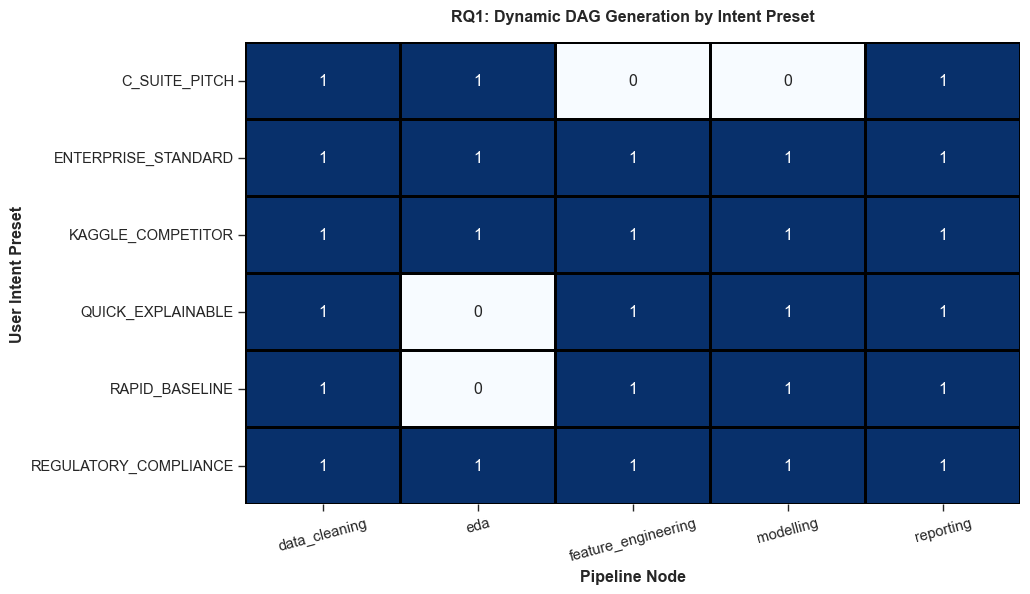

In [2]:
# Cell 2: RQ1 - Dynamic Routing Heatmap
# Parse the route string into binary columns
nodes = ['data_cleaning', 'eda', 'feature_engineering', 'modelling', 'reporting']
for node in nodes:
    df[node] = df['Executed Route'].apply(lambda x: 1 if node in str(x) else 0)

# Aggregate to see which preset triggers which node
heatmap_data = df.groupby('Preset')[nodes].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="Blues", annot=True, cbar=False, 
            linewidths=1, linecolor='black', fmt=".0f")

plt.title("RQ1: Dynamic DAG Generation by Intent Preset", pad=15, fontweight='bold')
plt.xlabel("Pipeline Node", fontweight='bold')
plt.ylabel("User Intent Preset", fontweight='bold')
plt.xticks(rotation=15)

heatmap_path = os.path.join(results_dir, "rq1_routing_heatmap.png")
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
plt.show()

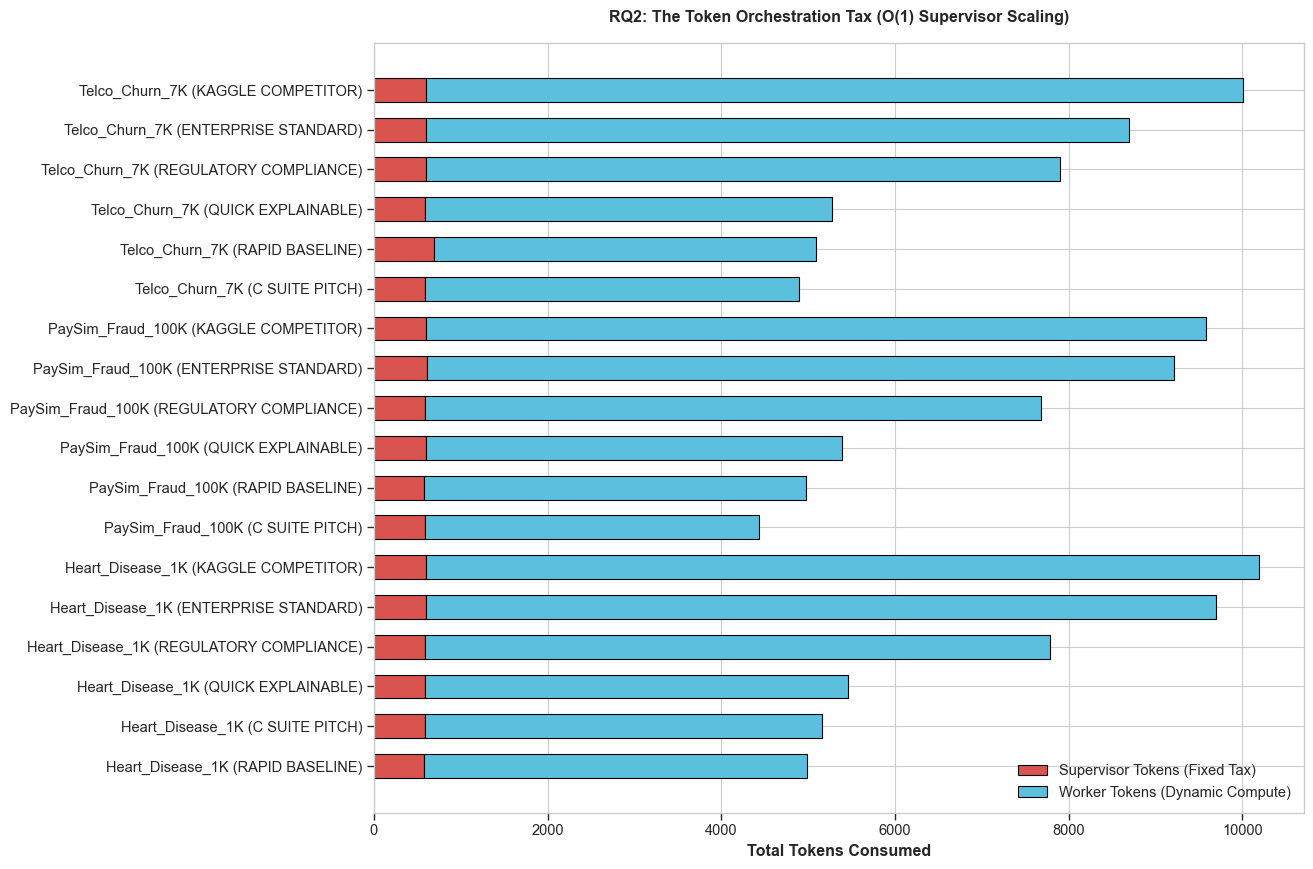

In [3]:
# Cell 3: RQ2 - Token Orchestration Tax (Horizontal)
# Sort by Dataset and then Total Tokens for a clean progression
df_sorted = df.sort_values(by=['Dataset', 'Total Tokens'])
run_labels = df_sorted['Dataset'] + " (" + df_sorted['Preset'].str.replace("_", " ") + ")"

# Made it taller (10) instead of wider to fit all 18 labels comfortably
plt.figure(figsize=(12, 10))
bar_height = 0.6
y = np.arange(len(df_sorted))

# Left bar (Supervisor Tax - O(1))
plt.barh(y, df_sorted['Supervisor Tokens'], height=bar_height, 
         label='Supervisor Tokens (Fixed Tax)', color='#d9534f', edgecolor='black')

# Right bar (Worker Compute - Variable)
# Notice 'bottom' is now 'left'
plt.barh(y, df_sorted['Worker Tokens'], height=bar_height, left=df_sorted['Supervisor Tokens'], 
         label='Worker Tokens (Dynamic Compute)', color='#5bc0de', edgecolor='black')

plt.title("RQ2: The Token Orchestration Tax (O(1) Supervisor Scaling)", pad=15, fontweight='bold')
plt.xlabel("Total Tokens Consumed", fontweight='bold') # Swapped to X-axis
plt.yticks(y, run_labels) # Swapped to Y-axis and removed rotation
plt.legend(loc='lower right') # Moved legend so it doesn't overlap the top bars

token_path = os.path.join(results_dir, "rq2_token_tax.png")
plt.savefig(token_path, dpi=300, bbox_inches='tight')
plt.show()

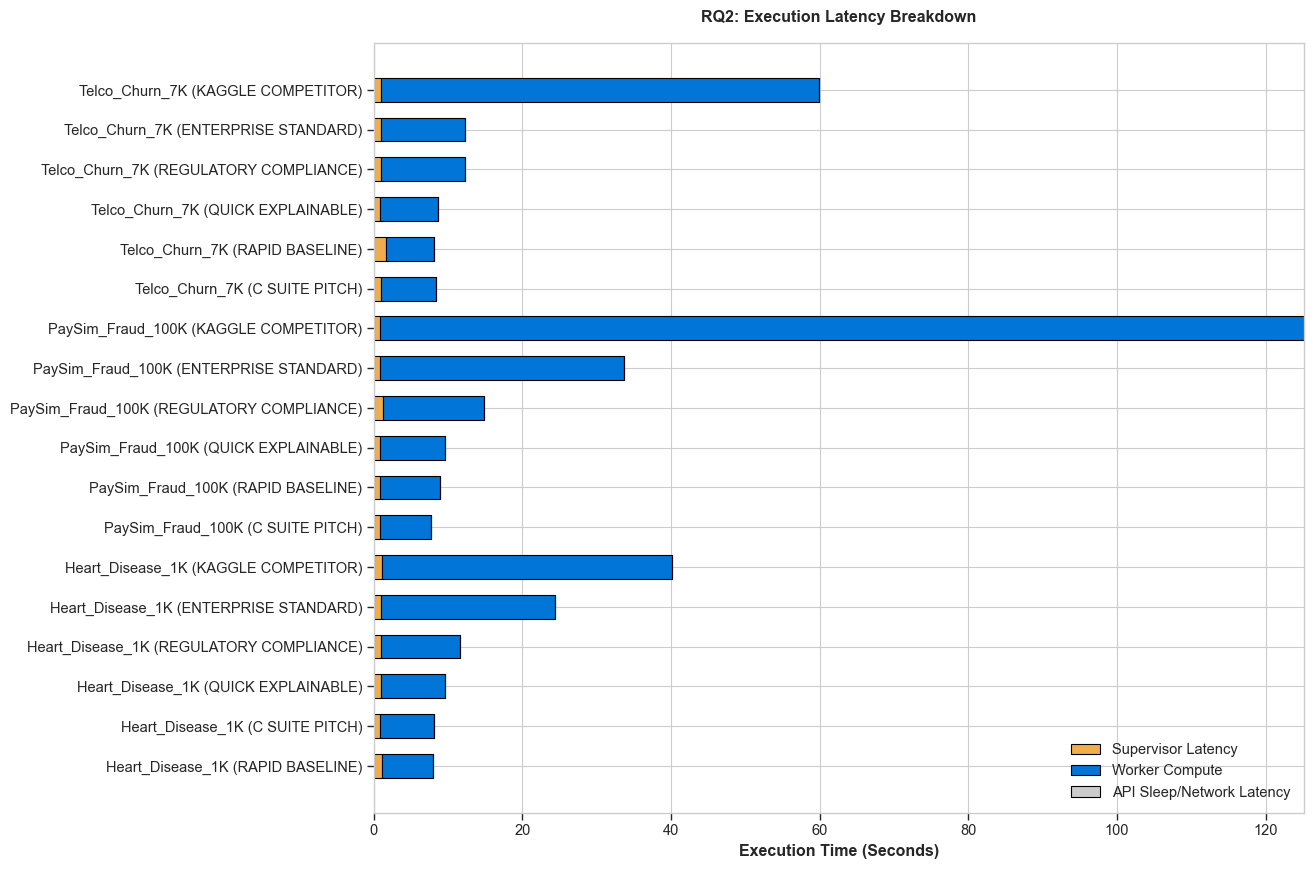

In [4]:
# Cell 4: RQ2 - Execution Latency Breakdown (Horizontal)
plt.figure(figsize=(12, 10))

# For simplicity, calculate theoretical sleep time (if not explicitly in csv, approx it)
# Assuming 'Runtime (s)' is gross, 'Worker Compute (s)' + 'Supervisor Latency (s)' is pure compute.
df_sorted['Sleep Time (s)'] = df_sorted['Runtime (s)'] - (df_sorted['Worker Compute (s)'] + df_sorted['Supervisor Latency (s)'])
df_sorted['Sleep Time (s)'] = df_sorted['Sleep Time (s)'].clip(lower=0) # Catch any rounding negatives

b1 = plt.barh(y, df_sorted['Supervisor Latency (s)'], height=bar_height, 
              label='Supervisor Latency', color='#f0ad4e', edgecolor='black')
b2 = plt.barh(y, df_sorted['Worker Compute (s)'], height=bar_height, left=df_sorted['Supervisor Latency (s)'], 
              label='Worker Compute', color='#0275d8', edgecolor='black')
b3 = plt.barh(y, df_sorted['Sleep Time (s)'], height=bar_height, 
              left=df_sorted['Supervisor Latency (s)'] + df_sorted['Worker Compute (s)'], 
              label='API Sleep/Network Latency', color='#cccccc', edgecolor='black')

plt.title("RQ2: Execution Latency Breakdown", pad=15, fontweight='bold')
plt.xlabel("Execution Time (Seconds)", fontweight='bold') # Swapped to X-axis
plt.yticks(y, run_labels) # Swapped to Y-axis
plt.legend(loc='lower right')

latency_path = os.path.join(results_dir, "rq2_latency_breakdown.png")
plt.savefig(latency_path, dpi=300, bbox_inches='tight')
plt.show()

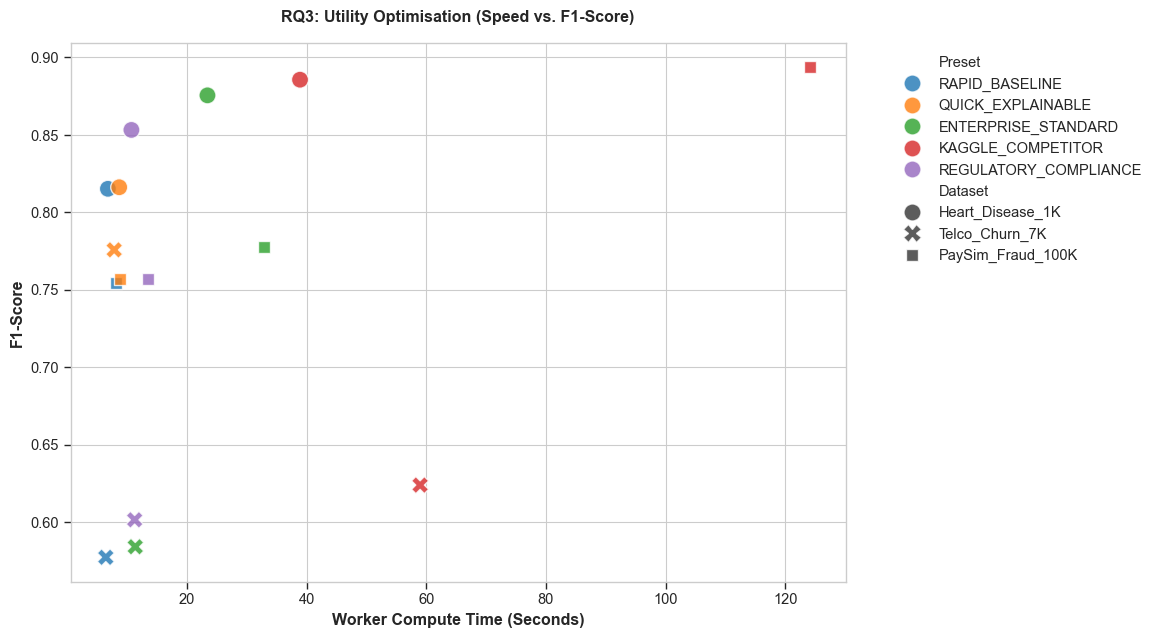

In [5]:
# Cell 5: RQ3 - Pareto Frontier (Speed vs Accuracy)
# Filter out runs that didn't train a model (e.g., C_SUITE_PITCH where F1 is N/A)
df_ml = df[pd.to_numeric(df['F1 Score'], errors='coerce').notnull()].copy()
df_ml['F1 Score'] = df_ml['F1 Score'].astype(float)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_ml, x='Worker Compute (s)', y='F1 Score', 
                hue='Preset', style='Dataset', s=150, alpha=0.8)

plt.title("RQ3: Utility Optimisation (Speed vs. F1-Score)", pad=15, fontweight='bold')
plt.xlabel("Worker Compute Time (Seconds)", fontweight='bold')
plt.ylabel("F1-Score", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

pareto_path = os.path.join(results_dir, "rq3_pareto_frontier.png")
plt.savefig(pareto_path, dpi=300, bbox_inches='tight')
plt.show()

                  Preset  Judge: Tech  Judge: Action  Judge: Align
0          C_SUITE_PITCH     8.666667       9.000000      9.666667
1    ENTERPRISE_STANDARD     9.333333       8.000000      9.000000
2      KAGGLE_COMPETITOR    10.000000       8.000000      9.000000
3      QUICK_EXPLAINABLE     9.000000       8.666667      9.333333
4         RAPID_BASELINE     8.666667       8.000000     10.000000
5  REGULATORY_COMPLIANCE     9.000000       9.666667     10.000000


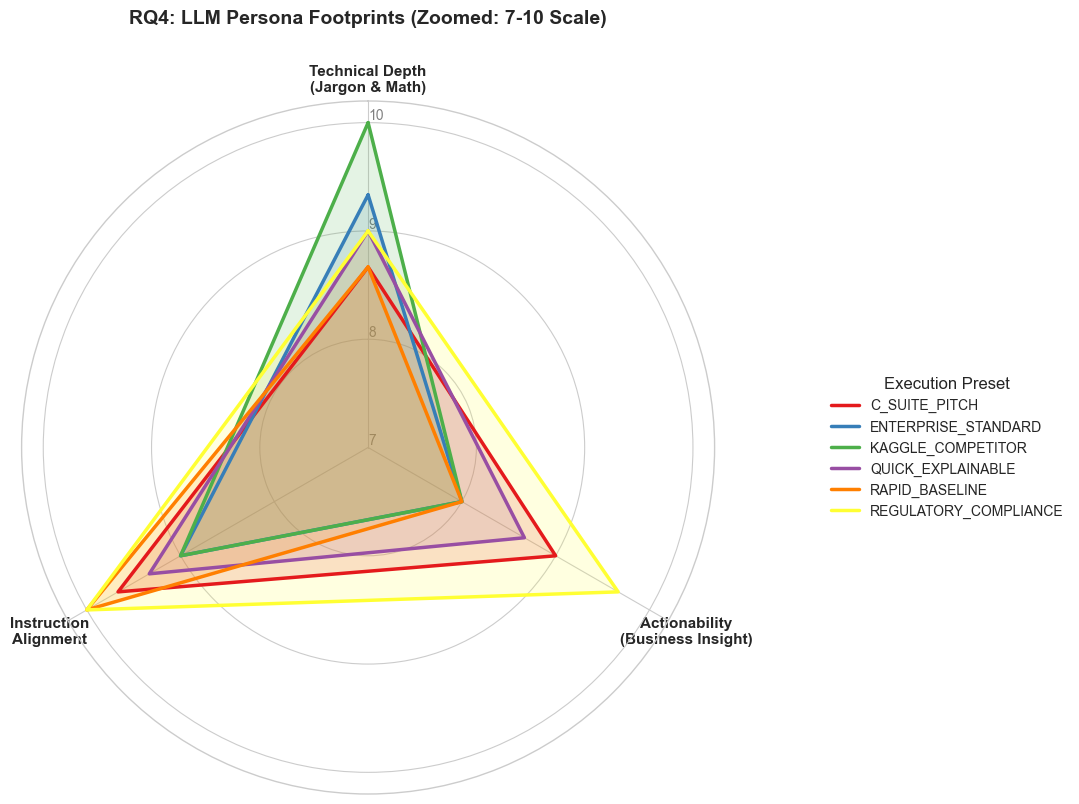

In [6]:
# Cell 6: RQ4 - Qualitative Alignment (The Persona Footprint Radar Chart)
import math

# Calculate the mean scores for each preset across all datasets
categories = ['Judge: Tech', 'Judge: Action', 'Judge: Align']
radar_data = df.groupby('Preset')[categories].mean().reset_index()

print(radar_data)

# Set up the radar chart angle parameters
N = len(categories)
angles = [n / float(N) * 2 * math.pi for n in range(N)]
angles += angles[:1] # Close the loop

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# Define colors for the 6 presets
colors = sns.color_palette("Set1", len(radar_data))

# Plot each preset
for i, row in radar_data.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1] # Close the loop
    
    ax.plot(angles, values, linewidth=2.5, linestyle='solid', label=row['Preset'], color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.15)

# Formatting the radar chart
ax.set_theta_offset(math.pi / 2)
ax.set_theta_direction(-1)

# Set the category labels
plt.xticks(angles[:-1], ['Technical Depth\n(Jargon & Math)', 'Actionability\n(Business Insight)', 'Instruction\nAlignment'], size=11, fontweight='bold')

# --- THE ZOOM EFFECT ---
# Set the absolute center of the radar to 7, and the outer edge to just past 10
ax.set_ylim(7, 10.2)
plt.yticks([7, 8, 9, 10], ["7", "8", "9", "10"], color="grey", size=10)
ax.set_rlabel_position(0) # Move the y-axis labels to point straight up

plt.title("RQ4: LLM Persona Footprints (Zoomed: 7-10 Scale)", y=1.1, fontweight='bold', fontsize=14)

# Place the legend neatly outside the chart
plt.legend(loc='center left', bbox_to_anchor=(1.15, 0.5), title="Execution Preset", title_fontsize='12', fontsize='10')

radar_path = os.path.join(results_dir, "rq4_persona_radar_zoomed.png")
plt.savefig(radar_path, dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Rishav Chanda\AppData\Local\Temp\ipykernel_15356\1824168206.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df_repair, x='Execution', y='Total Tokens', palette=['#5bc0de', '#d9534f'])
C:\Users\Rishav Chanda\AppData\Local\Temp\ipykernel_15356\1824168206.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_repair, x='Execution', y='API Calls', palette=['#5bc0de', '#d9534f'])
C:\Users\Rishav Chanda\AppData\Local\Temp\ipykernel_15356\1824168206.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplo

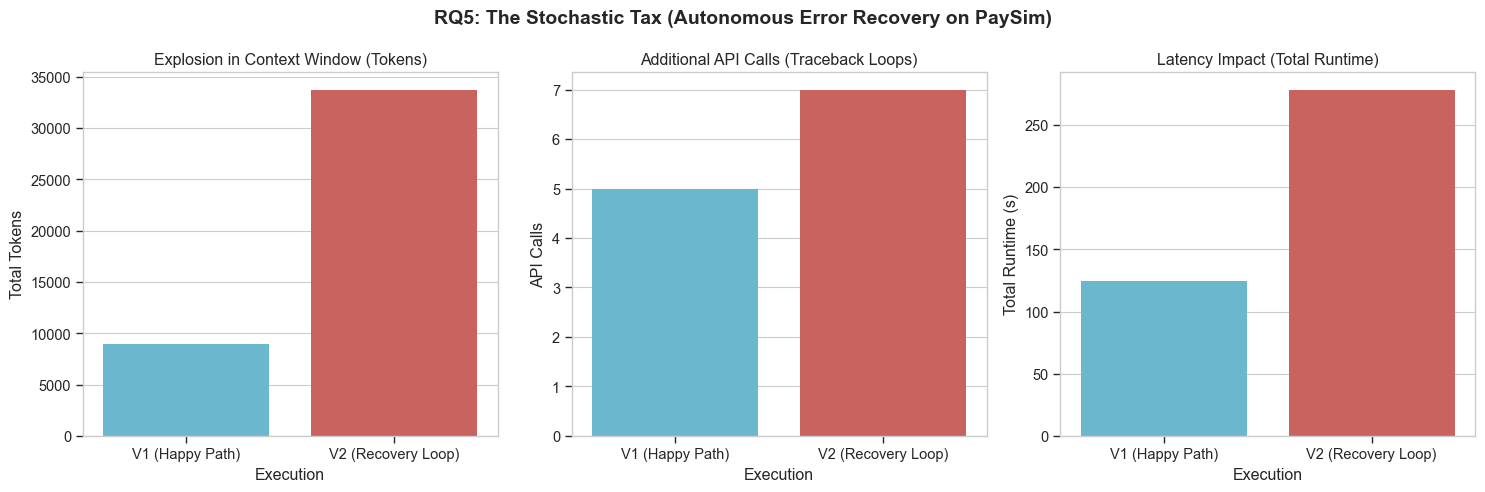

In [7]:
# Cell 7: RQ5 - The Cost of Self-Healing (Manual Data injection based on Case Study 3)
# Creating a mini-dataframe to contrast Happy Path (V1) vs Recovery Path (V2)
repair_data = {
    'Execution': ['V1 (Happy Path)', 'V2 (Recovery Loop)'],
    'Total Tokens': [8973, 33748],
    'API Calls': [5, 7],
    'Total Runtime (s)': [124.21, 278.43]
}
df_repair = pd.DataFrame(repair_data)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("RQ5: The Stochastic Tax (Autonomous Error Recovery on PaySim)", fontweight='bold', fontsize=14)

sns.barplot(ax=axes[0], data=df_repair, x='Execution', y='Total Tokens', palette=['#5bc0de', '#d9534f'])
axes[0].set_title("Explosion in Context Window (Tokens)")

sns.barplot(ax=axes[1], data=df_repair, x='Execution', y='API Calls', palette=['#5bc0de', '#d9534f'])
axes[1].set_title("Additional API Calls (Traceback Loops)")

sns.barplot(ax=axes[2], data=df_repair, x='Execution', y='Total Runtime (s)', palette=['#5bc0de', '#d9534f'])
axes[2].set_title("Latency Impact (Total Runtime)")

plt.tight_layout()
tax_path = os.path.join(results_dir, "rq5_stochastic_tax.png")
plt.savefig(tax_path, dpi=300, bbox_inches='tight')
plt.show()